In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ml-mania-2023/sample_submission.csv
/kaggle/input/ml-mania-2023/train.csv
/kaggle/input/ml-mania-2023/test.csv


In [2]:
# pip install tensorflow==2.0.0 

In [3]:
data=pd.read_csv("/kaggle/input/ml-mania-2023/train.csv")
# t_data=pd.read_csv("/kaggle/input/ml-mania-2023/train.csv")
test_data=pd.read_csv("/kaggle/input/ml-mania-2023/test.csv")

In [4]:
data.head()

,UDI,Air_temperature,Air_Speed,Process_temperature,Rotational_speed,Atmospheric_temperature,Tool_wear,Torque,Force_in_x_axis,Force_in_y_axis,Force_in_z_axis
0,1,298.1,13.67,308.6,1551,302.15,0,42.8,28.7141,-5.64032,81.108917
1,2,298.2,11.50,308.7,1408,302.15,3,46.3,28.815765,-5.483627,81.274582
2,3,298.1,11.25,308.5,1498,314.15,5,49.4,28.874094,-5.307098,81.407852
3,4,298.2,8.63,308.6,1433,314.15,7,39.5,28.890919,-5.11209,81.514557
4,5,298.2,11.92,308.7,1408,304.15,9,40.0,28.867971,-4.899905,81.600212


In [5]:
data.head()
data.drop(2966,axis=0,inplace=True)
ytrain=data.iloc[:,7]


In [6]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
scaler = MinMaxScaler(feature_range=(0, 2))
# scaler = StandardScaler()
newdata=scaler.fit_transform(data)
data=pd.DataFrame(newdata,columns=data.columns)

In [7]:
# # t_data.drop(2966,axis=0,inplace=True)
# data.head()
# from sklearn.preprocessing import StandardScaler
# scaler=StandardScaler()
# newdata=scaler.fit_transform(data)
# data=pd.DataFrame(newdata,columns=data.columns)

In [8]:
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# scaling=StandardScaler()
 
# # Use fit and transform method
# scaling.fit(t_data)
# Scaled_data=scaling.transform(t_data)
 
# # Set the n_components=6
# principal=PCA(n_components=6)
# principal.fit(Scaled_data)
# x=principal.transform(Scaled_data)
# x_temp_train=pd.DataFrame(x,columns=["Rotational_speed","Atmospheric_temperature","Tool_wear","Force_in_x_axis","Force_in_y_axis","Force_in_z_axis"])
# x_temp_train.head()

In [9]:
# print(principal.explained_variance_ratio_)

In [10]:
# # ytrain=data.iloc[:,7]
d=data.drop("Torque",axis=1)
xtrain=d.drop("UDI",axis=1)


In [11]:
# xtrain=xtrain.iloc[:2966,:]
# xtrain.drop(2967,axis=0,inplace=True)
print(xtrain.shape)
xtrain.head()


(3998, 9)


,Air_temperature,Air_Speed,Process_temperature,Rotational_speed,Atmospheric_temperature,Tool_wear,Force_in_x_axis,Force_in_y_axis,Force_in_z_axis
0,0.756757,0.892573,0.935484,0.445867,0.526316,0.000000,1.500673,1.295149,0.312435
1,0.783784,0.748674,0.967742,0.279395,0.526316,0.024390,1.503094,1.303661,0.313073
2,0.756757,0.732095,0.903226,0.384168,1.789474,0.040650,1.504483,1.313250,0.313586
3,0.783784,0.558355,0.935484,0.308498,1.789474,0.056911,1.504884,1.323843,0.313997
4,0.783784,0.776525,0.967742,0.279395,0.736842,0.073171,1.504337,1.335369,0.314327


In [12]:
# ytrain=ytrain.drop(2967,axis=0,inplace=True)

print(ytrain.shape)
ytrain.head()

(3998,)


0    42.8
1    46.3
2    49.4
3    39.5
4    40.0
Name: Torque, dtype: float64

In [13]:
# xtrain.describe()

In [14]:
# data.describe()

In [15]:
import seaborn as sb
import matplotlib.pyplot as plt

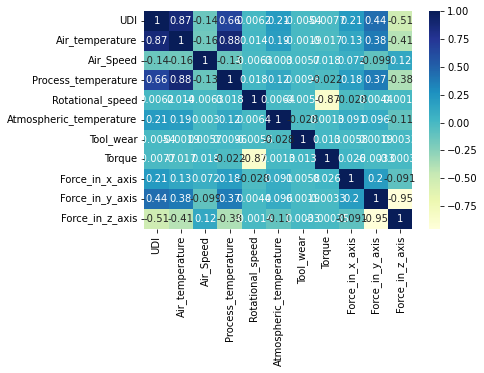

In [16]:
dataplot = sb.heatmap(data.corr(), cmap="YlGnBu", annot=True)

In [17]:
xtrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3998 entries, 0 to 3997
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Air_temperature          3998 non-null   float64
 1   Air_Speed                3998 non-null   float64
 2   Process_temperature      3998 non-null   float64
 3   Rotational_speed         3998 non-null   float64
 4   Atmospheric_temperature  3998 non-null   float64
 5   Tool_wear                3998 non-null   float64
 6   Force_in_x_axis          3998 non-null   float64
 7   Force_in_y_axis          3998 non-null   float64
 8   Force_in_z_axis          3998 non-null   float64
dtypes: float64(9)
memory usage: 281.2 KB


In [18]:
# xtrain=xtrain.drop("Atmospheric_temperature",axis=1)
# xtrain=xtrain.drop("Air_temperature",axis=1)
# xtrain=xtrain.drop("Air_Speed",axis=1)
# xtrain=xtrain.drop("Force_in_x_axis",axis=1)
# xtrain=xtrain.drop("Force_in_y_axis",axis=1)
# xtrain=xtrain.drop("Force_in_z_axis",axis=1)
xtrain=xtrain.drop("Tool_wear",axis=1)
xtrain=xtrain.drop("Process_temperature",axis=1)




In [19]:
test_data.head()

,UDI,Air_temperature,Air_Speed,Process_temperature,Rotational_speed,Atmospheric_temperature,Tool_wear,Force_in_x_axis,Force_in_y_axis,Force_in_z_axis
0,4000,302.0,17.04,311.0,1420,309.15,144,8.522236,-0.484429,20.344934
1,4001,302.1,15.37,311.2,1422,309.15,146,8.525336,-0.480634,20.253832
2,4002,302.1,12.29,311.2,1598,309.15,148,8.528436,-0.476839,20.162729
3,4003,302.1,9.17,311.2,1454,309.15,153,8.531535,-0.473045,20.071627
4,4004,302.1,14.62,311.2,1519,308.15,155,8.534635,-0.469250,19.980524


In [20]:
xtest=test_data.drop("UDI",axis=1)
# xtest=xtest.drop("Atmospheric_temperature",axis=1)
# xtest=xtest.drop("Air_temperature",axis=1)
# xtest=xtest.drop("Force_in_y_axis",axis=1)
# xtest=xtest.drop("Force_in_z_axis",axis=1)
# xtest=xtest.drop("Force_in_x_axis",axis=1)
xtest=xtest.drop("Tool_wear",axis=1)
# xtest=xtest.drop("Air_Speed",axis=1)
xtest=xtest.drop("Process_temperature",axis=1)




In [21]:
newdata=scaler.fit_transform(xtest)
xtest=pd.DataFrame(newdata,columns=xtest.columns)

In [22]:

xtest.head()

,Air_temperature,Air_Speed,Rotational_speed,Atmospheric_temperature,Force_in_x_axis,Force_in_y_axis,Force_in_z_axis
0,0.518519,1.356688,0.257905,1.368421,0.000000,0.000000,2.000000
1,0.592593,1.223726,0.260384,1.368421,0.002002,0.002002,1.997998
2,0.592593,0.978503,0.478611,1.368421,0.004004,0.004004,1.995996
3,0.592593,0.730096,0.300062,1.368421,0.006006,0.006006,1.993994
4,0.592593,1.164013,0.380657,1.263158,0.008008,0.008008,1.991992


In [23]:
# from sklearn.decomposition import PCA
# pca = PCA(n_components=6)
# xtrain=pca.fit_transform(xtrain)
# xtest=pca.fit_transform(xtest)

In [24]:
# pca.explained_variance_ratio_

In [25]:
from sklearn.model_selection import train_test_split
  
X_train, X_test,y_train, y_test = train_test_split(xtrain,ytrain,random_state=50,test_size=0.20)

In [26]:
# X_train=pd.DataFrame(X_train,columns=X_train.columns)

In [27]:
# y_train=pd.DataFrame(y_train,columns=["Torque"])

In [28]:
y_train.head()

3237    26.8
1951    22.7
1940    35.6
2602    41.5
3902    34.6
Name: Torque, dtype: float64

In [29]:
# from sklearn.linear_model import HuberRegressor
# regressor=HuberRegressor(max_iter=5000)
# regressor.fit(X_train,y_train)

In [30]:
# training_data=X_train
# training_data["Torque"]=y_train

In [31]:
# training_data.head()

In [32]:
# pip install autogluon

In [33]:
# from autogluon.tabular import TabularPredictor
# regressor = TabularPredictor(label="Torque",problem_type="regression")
# regressor.fit(train_data=training_data)

In [34]:
# predictor = TabularPredictor.load("AutogluonModels/ag-20230208_135818/")

In [35]:
# ypred=predictor.predict(X_test)

In [36]:
# perf = predictor.evaluate_predictions(y_true=y_test, y_pred=ypred, auxiliary_metrics=True)

In [37]:
# xtest['Force_in_x_axis'] = xtest['Force_in_x_axis'].astype(float)
# xtrain['Force_in_x_axis'] = xtrain['Force_in_x_axis'].astype(float)
# xtest['Force_in_y_axis'] = xtest['Force_in_y_axis'].astype(float)
# xtrain['Force_in_y_axis'] = xtrain['Force_in_y_axis'].astype(float)
# xtest['Force_in_z_axis'] = xtest['Force_in_z_axis'].astype(float)
# xtrain['Force_in_z_axis'] = xtrain['Force_in_z_axis'].astype(float)

In [38]:
# X_test['Force_in_x_axis'] = X_test['Force_in_x_axis'].astype(float)
# X_train['Force_in_x_axis'] = X_train['Force_in_x_axis'].astype(float)
# X_test['Force_in_y_axis'] = X_test['Force_in_y_axis'].astype(float)
# X_train['Force_in_y_axis'] = X_train['Force_in_y_axis'].astype(float)
# X_test['Force_in_z_axis'] = X_test['Force_in_z_axis'].astype(float)
# X_train['Force_in_z_axis'] = X_train['Force_in_z_axis'].astype(float)

In [39]:
# from sklearn.linear_model import BayesianRidge
# regressor=BayesianRidge()
# regressor.fit(X_train,y_train)

In [40]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.tree import DecisionTreeRegressor
# regressor=DecisionTreeRegressor(random_state=30)
# regressor.fit(X_train,y_train)

In [41]:
# pip install lazypredict

In [42]:
# import lazypredict
# from lazypredict.Supervised import LazyRegressor
# regressor=LazyRegressor()
# model,predict=regressor.fit(X_train,X_test,y_train,y_test)

In [43]:
# model

In [44]:
# predict

In [45]:
from sklearn.ensemble import HistGradientBoostingRegressor
regressor=HistGradientBoostingRegressor(learning_rate=0.11,loss="absolute_error",max_depth=2,max_iter=55,l2_regularization=1.4,max_leaf_nodes=10,min_samples_leaf=5)
regressor.fit(xtrain,ytrain)
# regressor.score(X_test,y_test)

HistGradientBoostingRegressor(l2_regularization=1.4, learning_rate=0.11,
                              loss='absolute_error', max_depth=2, max_iter=55,
                              max_leaf_nodes=10, min_samples_leaf=5)

In [46]:
# from sklearn.ensemble import GradientBoostingRegressor
# regressor2 = GradientBoostingRegressor(n_estimators=350,learning_rate=0.02,min_samples_leaf=10,max_depth=2,loss='huber',random_state=1,min_samples_split=5,max_features="auto",alpha=0.9)
# regressor2.fit(X_train,y_train)
# regressor2.score(X_test,y_test)

In [47]:
# from sklearn.ensemble import AdaBoostRegressor
# regressor=AdaBoostRegressor(n_estimators=1000,learning_rate=1.0,random_state=0,loss="linear")
# regressor.fit(X_train,y_train)
# regressor.score(X_test,y_test)

In [48]:
# from sklearn.linear_model import PoissonRegressor
# regressor1=PoissonRegressor(alpha=0,max_iter=2020,tol=1e-8)
# regressor1.fit(X_train,y_train)
# regressor1.score(X_test,y_test)

In [49]:
# from sklearn.linear_model import TweedieRegressor
# regressor2=TweedieRegressor(power=1.9, alpha=0.00190,link="log")
# regressor2.fit(X_train,y_train)
# regressor2.score(X_train,y_train)

In [50]:
# from sklearn.neural_network import MLPRegressor
# regressor3=MLPRegressor(
# hidden_layer_sizes=1000,solver="sgd",alpha=1,learning_rate="adaptive",
# learning_rate_init=0.001,momentum=0.92)
# regressor3.fit(xtrain,ytrain)
# # regressor.score(X_test,y_test)

In [51]:
# # ypred1=regressor1.predict(xtest)
# # ypred2=regressor2.predict(xtest)
# # ypred=(0.65*ypred1)+(0.35*ypred2)
# ypred=regressor2.predict(X_test)
# # ypred=regressor2.predict(xtest)
# # ypred=regressor.predict(X_test)
# from sklearn.metrics import r2_score
# print(r2_score(y_test,ypred))


In [52]:
# from sklearn.svm import SVR
# regressor = SVR(kernel = 'rbf')
# regressor.fit(X_train, y_train)

In [53]:
# from sklearn.ensemble import GradientBoostingRegressor
# reg1 = GradientBoostingRegressor(n_estimators=350,learning_rate=0.01,min_samples_leaf=5,max_depth=3,random_state=1)

# from sklearn.ensemble import RandomForestRegressor
# reg2 = RandomForestRegressor(n_jobs=8,min_samples_leaf=10 ,max_depth=4,n_estimators = 550, random_state =1,oob_score = True)

# from sklearn.svm import SVR
# reg3 = SVR(kernel = 'rbf')

# from xgboost import XGBRegressor
# reg4=XGBRegressor(learning_rate =0.01,
#  n_estimators=1000,
#  max_depth=11,
#  min_child_weight=1,
#  gamma=0.1,
#  subsample=0.8,
#  colsample_bytree=0.8,
#  nthread=4)

# import lightgbm as lgb
# reg5=lgb.LGBMRegressor(n_estimators=1050,max_depth=3,learning_rate=0.085)
# # reg5.fit(X_train,y_train)

# # import catboost as cb
# # reg6=cb.CatBoostRegressor(loss_function="RMSE",iterations=200,learning_rate=0.01,max_depth=3)
# # train_dataset = cb.Pool(X_train, y_train) 
# # grid = {'iterations': [100, 250, 350],
# #         'learning_rate': [0.03, 0.01],
# #         'depth': [2, 4, 6, 8],
# #         'l2_leaf_reg': [0.2, 0.5, 1, 3]}
# # reg6.grid_search(grid, train_dataset)



# from sklearn.ensemble import VotingRegressor
# regressor = VotingRegressor(estimators=[('gb', reg1), ('rf', reg2),('xg',reg4),('lgm',reg5)])
# regressor.fit(X_train,y_train)

In [54]:
# from sklearn.ensemble import RandomForestRegressor
# regressor = RandomForestRegressor(n_estimators = 1000, random_state = 10)
# regressor.fit(X_train, y_train)

In [55]:
# import lightgbm as lgb
# regressor2=lgb.LGBMRegressor(n_estimators=350,max_depth=4,learning_rate=0.01)
# regressor2.fit(X_train,y_train)
# regressor2.score(X_test,y_test)

In [56]:
# from sklearn.linear_model import TheilSenRegressor
# regressor=TheilSenRegressor()
# regressor.fit(X_train,y_train)
# regressor.score(X_test,y_test)

In [57]:
# import catboost as cb
# regressor3=cb.CatBoostRegressor(loss_function="RMSE")


In [58]:
# train_dataset = cb.Pool(xtrain, ytrain) 
# test_dataset = cb.Pool(X_test, y_test)

In [59]:
# grid = {'iterations': [100, 250, 350,450,550,650],
#         'learning_rate': [0.03, 0.01,0.02],
#         'depth': [2, 3,4, 6, 8],
#         'l2_leaf_reg': [0.2, 0.5, 1, 2]}
# regressor3.grid_search(grid, train_dataset)

In [60]:
# For Submission
# from sklearn.ensemble import RandomForestRegressor
# regressor3 = RandomForestRegressor(n_jobs=8,min_samples_leaf=10 ,max_depth=4,n_estimators = 1100, random_state =1,oob_score = True)
# regressor3.fit(xtrain, ytrain)

In [61]:
#For Submission
# from sklearn.svm import SVR
# regressor = SVR(kernel = 'rbf')
# regressor.fit(xtrain, ytrain)

In [62]:
# from xgboost import XGBRegressor
# regressor=XGBRegressor(learning_rate =0.0045,
#  n_estimators=1500,
#  max_depth=3,
#  min_child_weight=1,
#  gamma=0.065,
#  subsample=0.8,
#  colsample_bytree=0.8,
#  nthread=4,
#  scale_pos_weight=1)
# regressor.fit(X_train,y_train)

In [63]:
# from sklearn.model_selection import cross_val_score, KFold
# kfold = KFold(n_splits=10, shuffle=True)
# kf_cv_scores = cross_val_score(regressor, xtrain, ytrain, cv=kfold )
# print("K-fold CV average score: %.2f" % kf_cv_scores.mean())

In [64]:
# scores = cross_val_score(regressor, xtrain, ytrain,cv=10)
# print("Mean cross-validation score: %.2f" % scores.mean())


In [65]:
# xtest.info()

In [66]:
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler
# scaling=StandardScaler()
 
# # Use fit and transform method
# scaling.fit(test_data.iloc[:,1:])
# Scaled_data=scaling.transform(test_data.iloc[:,1:])
 
# # Set the n_components=3
# principal=PCA(n_components=6)
# principal.fit(Scaled_data)
# x=principal.transform(Scaled_data)
# x_temp_test=pd.DataFrame(x,columns=["Rotational_speed","Atmospheric_temperature","Tool_wear","Force_in_x_axis","Force_in_y_axis","Force_in_z_axis"])
# print(x_temp_test.shape)
# x_temp_test.head()


In [67]:
# newdata=scaler.fit_transform(xtest)
# xtest=pd.DataFrame(newdata,columns=xtest.columns)

In [68]:
ypred=regressor.predict(xtest)

In [69]:
# ypred1=regressor1.predict(X_test)
# ypred2=regressor2.predict(X_test)
# ypred3=regressor3.predict(X_test)
# ypred=(0.33*ypred1)+(0.33*ypred2)+(0.33*ypred3)


In [70]:
# ypred.shape

In [71]:
ypred

array([48.67156637, 48.67156637, 35.68335711, 45.50284442, 41.09284607,
       52.73353586, 49.71604366, 43.36930288, 52.33449222, 45.21717344,
       33.26639701, 34.96816461, 45.9155258 , 53.24363455, 28.57553807,
       28.07702466, 44.07330288, 32.57771262, 22.40474075, 26.55542664,
       38.039813  , 53.24363455, 45.50284442, 31.24454021, 52.40458166,
       53.313724  , 28.57553807, 37.84103279, 37.84103279, 45.50284442,
       31.15157517, 16.36679874, 45.98561525, 50.17379562, 27.54957457,
       34.53337869, 45.50284442, 45.9155258 , 34.88202593, 39.23987869,
       37.84103279, 27.54957457, 39.23987869, 37.84103279, 45.98561525,
       48.60147692, 23.83159748, 48.60147692, 45.50284442, 12.30969103,
       41.09284607, 45.50284442, 50.10370618, 37.84103279, 14.62260911,
       45.50284442, 23.83159748, 35.68335711, 43.29921344, 45.50284442,
       45.21717344, 53.75325255, 22.40474075, 45.9155258 , 21.90667123,
       44.00321344, 41.02275663, 45.21717344, 48.60147692, 49.31

In [72]:
submission_df = pd.DataFrame({'UDI': test_data['UDI'].values.flatten(), 'Torque': ypred.flatten()})
submission_df.to_csv('submission.csv', index=False)

In [73]:
# from sklearn.metrics import r2_score
# print(r2_score(y_test,ypred))